# Predicción del precio del aguacate por medio de regresion linear multiple

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             confusion_matrix, classification_report,
                             f1_score, precision_score, recall_score,
                             roc_curve, roc_auc_score)
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('../docs/clean_avocado.csv')
df.head()

,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year,...,region_SOUTHCAROLINA,region_SOUTHCENTRAL,region_SOUTHEAST,region_SPOKANE,region_STLOUIS,region_SYRACUSE,region_TAMPA,region_TOTALUS,region_WEST,region_WESTTEXNEWMEXICO
0,-0.162848,-0.115021,-0.616377,0.369351,-0.286600,-0.504590,-0.260728,-0.671562,-0.646579,2015,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.110121,-0.183584,-0.744123,0.299899,-0.241293,-0.465177,-0.225881,-0.660104,-0.646579,2015,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.217387,0.150551,-0.695336,0.612314,-0.049524,-0.533632,-0.287034,-0.645580,-0.646579,2015,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.821935,-0.024995,-0.590266,0.466825,-0.189427,-0.683308,-0.422779,-0.578466,-0.646579,2015,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.294666,-0.215146,-0.645003,0.293577,-0.179170,-0.655747,-0.402128,-0.477375,-0.646579,2015,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Empezamos comprobobando que columnas tienen buena relación entre ellas mediante una matriz de correlación

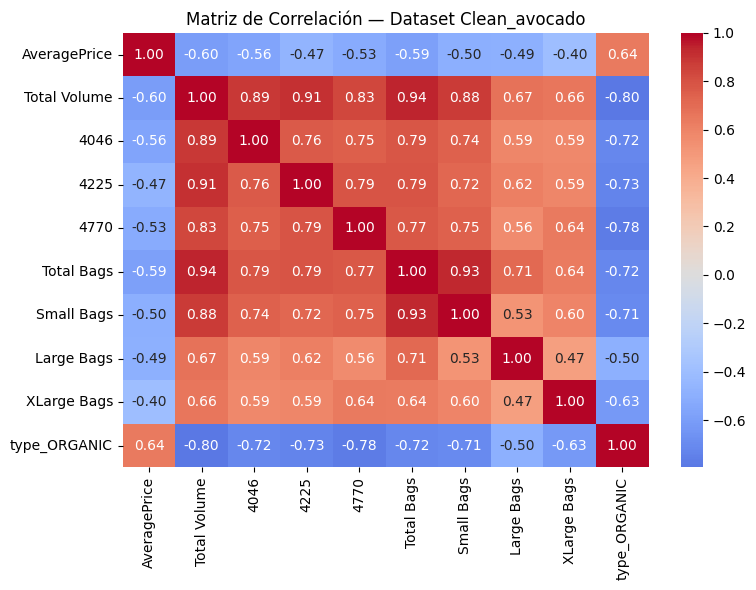

In [2]:
plt.figure(figsize=(8, 6))
numeric_cols = ['AveragePrice','Total Volume', '4046', '4225', '4770',
                'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type_ORGANIC']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación — Dataset Clean_avocado')
plt.tight_layout()
plt.show()

### Aqui podemos evidenciar que la vas variables de volumen están altamente correlacionadas entre ellas al igual que las bolsas pero ninguna se relaciona bien con el precio y por el analisis previo sabemos que aunque no se evidencia aqui el tipo de aguacate esta relacionado con el precio asi que haremos varias pruebas para encontrar la mejor combinación de variables

## Preparamos los datos y y partimos el Train/Test
### para estas primera prueba utilizaremos todas las variables de volumen

In [3]:

region_dummies = [col for col in df.columns if col.startswith('region_')]

X_reg = df[['type_ORGANIC','Total Volume', '4046', '4225', '4770','month','week'] 
    + list(region_dummies)]
y_reg = df['AveragePrice']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Datos de entrenamiento: {X_train_reg.shape}")
print(f"Datos de prueba: {X_test_reg.shape}")

Datos de entrenamiento: (14347, 60)
Datos de prueba: (3587, 60)


In [4]:
modelo_reg = LinearRegression()
modelo_reg.fit(X_train_reg, y_train_reg)

# Predecir sobre el conjunto de prueba
y_pred_reg = modelo_reg.predict(X_test_reg)

print(f"Coeficientes: {modelo_reg.coef_}")
print(f"Intercepto: {modelo_reg.intercept_:.4f}")
print(f"\nInterpretación:")
for col, coef in zip(X_reg.columns, modelo_reg.coef_):
    print(f"  {col}: {coef:+.4f} (por cada unidad de aumento, AvegarePrice cambia en {coef:+.4f})")

Coeficientes: [-0.3872747  -1.39374758  0.15896811  0.32604078 -0.10089137  0.05348742
 -0.00523126  0.06806912  0.93243121 -0.5241883   0.82939498  0.22402576
  1.40238341  0.55522863  0.95284842 -0.25220015 -0.40338399 -0.13152061
  0.24417478  0.010747   -0.03473566  1.10739801  0.43611624  1.13461911
 -0.09056103 -0.40378219  0.13063819 -0.02169077  0.67192671 -0.61141981
  0.2538278   1.28778504 -0.37672411 -0.12669682  1.64765356  1.89804517
  0.73395242  0.37789407  0.84580699 -0.01893647 -0.20491364  1.02867972
  0.25191171  0.5007914  -0.13862352 -0.49302107  0.66610697  0.28884498
  1.1975633   0.56512423  0.22191912  0.6319724   1.22851723 -0.42261803
  0.00287609 -0.07270065  0.10959264  2.11845542  1.25596011  0.11057852]
Intercepto: -0.4030

Interpretación:
  type_ORGANIC: -0.3873 (por cada unidad de aumento, AvegarePrice cambia en -0.3873)
  Total Volume: -1.3937 (por cada unidad de aumento, AvegarePrice cambia en -1.3937)
  4046: +0.1590 (por cada unidad de aumento, Ave

## Tabla comparativa

In [5]:
df_pred_reg = pd.DataFrame({
    'Actual': y_test_reg.values, 
    'Predicho': y_pred_reg.round(2), 
    'Error': (y_test_reg.values - y_pred_reg).round(4)
})
df_pred_reg.head(10)

,Actual,Predicho,Error
0,0.944418,1.13,-0.1859
1,0.021696,0.21,-0.1900
2,0.601692,0.53,0.0691
3,-0.452846,-0.46,0.0047
4,-0.848298,-0.71,-0.1387
5,-0.321029,-0.42,0.0958
6,1.656231,1.44,0.2160
7,-1.006479,-0.64,-0.3627
8,-1.586476,-1.05,-0.5377
9,1.366233,1.72,-0.3529


## Evaluación del modelo

In [6]:
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"R² (Coeficiente de determinación): {r2:.4f}")
print(f"MSE (Error Cuadrático Medio):      {mse:.4f}")
print(f"RMSE (Raíz del MSE):               {rmse:.4f}")
print(f"\nEl modelo explica el {r2*100:.1f}% de la variabilidad en AvergePrice.")

R² (Coeficiente de determinación): 0.6498
MSE (Error Cuadrático Medio):      0.3536
RMSE (Raíz del MSE):               0.5947

El modelo explica el 65.0% de la variabilidad en AvergePrice.


## Ahora intentaremos usando solo el volumen total

In [7]:

X_reg = df[['type_ORGANIC','Total Volume','month','week'] 
    + list(region_dummies)]
y_reg = df['AveragePrice']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Datos de entrenamiento: {X_train_reg.shape}")
print(f"Datos de prueba: {X_test_reg.shape}")

Datos de entrenamiento: (14347, 57)
Datos de prueba: (3587, 57)


In [8]:
modelo_reg = LinearRegression()
modelo_reg.fit(X_train_reg, y_train_reg)

# Predecir sobre el conjunto de prueba
y_pred_reg = modelo_reg.predict(X_test_reg)

print(f"Coeficientes: {modelo_reg.coef_}")
print(f"Intercepto: {modelo_reg.intercept_:.4f}")
print(f"\nInterpretación:")
for col, coef in zip(X_reg.columns, modelo_reg.coef_):
    print(f"  {col}: {coef:+.4f} (por cada unidad de aumento, AvegarePrice cambia en {coef:+.4f})")

Coeficientes: [-0.48812456 -1.11081799  0.0525123  -0.00521406  0.19817445  1.0062924
 -0.60938771  0.77946062  0.13632944  1.60926507  0.54989632  1.0829303
 -0.17079004 -0.32943947 -0.09316235  0.29660115  0.06862812 -0.02092488
  1.27241957  0.41148834  1.23522109 -0.16653389 -0.34418017  0.08819506
  0.11131597  0.81597664 -0.61309565  0.16229011  1.37221892 -0.32376348
 -0.29035557  1.76507457  1.9993852   0.58392151  0.38437381  0.95669658
  0.10711125 -0.30015654  1.14463657  0.36643508  0.5032056  -0.09589874
 -0.37295392  0.87752477  0.44528201  1.4108285   0.67770459  0.24204771
  0.74004667  1.29426576 -0.32086181  0.0726308  -0.1723424   0.02650562
  2.27343431  1.39829008  0.19783091]
Intercepto: -0.3992

Interpretación:
  type_ORGANIC: -0.4881 (por cada unidad de aumento, AvegarePrice cambia en -0.4881)
  Total Volume: -1.1108 (por cada unidad de aumento, AvegarePrice cambia en -1.1108)
  month: +0.0525 (por cada unidad de aumento, AvegarePrice cambia en +0.0525)
  week: 

## Tabla comparativa

In [9]:
df_pred_reg = pd.DataFrame({
    'Actual': y_test_reg.values, 
    'Predicho': y_pred_reg.round(2), 
    'Error': (y_test_reg.values - y_pred_reg).round(4)
})
df_pred_reg.head(10)

,Actual,Predicho,Error
0,0.944418,1.24,-0.2998
1,0.021696,0.06,-0.0402
2,0.601692,0.52,0.0792
3,-0.452846,-0.45,-0.0044
4,-0.848298,-0.75,-0.1028
5,-0.321029,-0.52,0.2036
6,1.656231,1.47,0.1906
7,-1.006479,-0.64,-0.3691
8,-1.586476,-0.97,-0.6119
9,1.366233,1.61,-0.2408


## Evaluación del modelo

In [10]:
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"R² (Coeficiente de determinación): {r2:.4f}")
print(f"MSE (Error Cuadrático Medio):      {mse:.4f}")
print(f"RMSE (Raíz del MSE):               {rmse:.4f}")
print(f"\nEl modelo explica el {r2*100:.1f}% de la variabilidad en AvergePrice.")

R² (Coeficiente de determinación): 0.6375
MSE (Error Cuadrático Medio):      0.3661
RMSE (Raíz del MSE):               0.6050

El modelo explica el 63.7% de la variabilidad en AvergePrice.


## Ahora solo con las variables de volumen de manera independiente

In [11]:

X_reg = df[['type_ORGANIC','4046', '4225', '4770','month','week'] 
    + list(region_dummies)]
y_reg = df['AveragePrice']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Datos de entrenamiento: {X_train_reg.shape}")
print(f"Datos de prueba: {X_test_reg.shape}")

Datos de entrenamiento: (14347, 59)
Datos de prueba: (3587, 59)


In [12]:
modelo_reg = LinearRegression()
modelo_reg.fit(X_train_reg, y_train_reg)

# Predecir sobre el conjunto de prueba
y_pred_reg = modelo_reg.predict(X_test_reg)

print(f"Coeficientes: {modelo_reg.coef_}")
print(f"Intercepto: {modelo_reg.intercept_:.4f}")
print(f"\nInterpretación:")
for col, coef in zip(X_reg.columns, modelo_reg.coef_):
    print(f"  {col}: {coef:+.4f} (por cada unidad de aumento, AvegarePrice cambia en {coef:+.4f})")

Coeficientes: [ 1.00914048 -0.0410587  -0.01111868 -0.127689    0.05142661 -0.00286679
 -0.53007442  0.13735984 -0.55389617 -0.01039607 -0.14825873 -0.21728232
  0.28931511  0.0482009  -0.8102955  -0.66974467 -1.1330574  -0.68784453
 -0.58677077 -0.15404646 -0.3845465  -0.02884643  0.68772025 -1.22021817
 -0.58339369 -0.06656227 -0.43839385 -0.7010405  -0.64385792 -0.35587609
 -0.11984499 -0.74645036 -0.62977295  0.59383144  0.3380942  -0.17079398
 -0.09124884  0.29477384 -0.80151462 -0.42200621 -0.11307343 -0.59113494
  0.08902843 -0.50499614 -0.77676274  0.30025321 -0.30504047  0.44138095
 -0.35539676 -0.22125139 -1.01065072 -0.14558541 -0.3790903  -0.31091933
 -0.14470447 -0.41735883 -0.25365132 -0.47028893 -0.63830775]
Intercepto: -0.4378

Interpretación:
  type_ORGANIC: +1.0091 (por cada unidad de aumento, AvegarePrice cambia en +1.0091)
  4046: -0.0411 (por cada unidad de aumento, AvegarePrice cambia en -0.0411)
  4225: -0.0111 (por cada unidad de aumento, AvegarePrice cambia en 

## Tabla comparativa

In [13]:
df_pred_reg = pd.DataFrame({
    'Actual': y_test_reg.values, 
    'Predicho': y_pred_reg.round(2), 
    'Error': (y_test_reg.values - y_pred_reg).round(4)
})
df_pred_reg.head(10)

,Actual,Predicho,Error
0,0.944418,1.20,-0.2577
1,0.021696,0.18,-0.1601
2,0.601692,0.74,-0.1411
3,-0.452846,-0.85,0.3956
4,-0.848298,-0.71,-0.1335
5,-0.321029,0.07,-0.3905
6,1.656231,1.29,0.3658
7,-1.006479,-0.59,-0.4120
8,-1.586476,-1.04,-0.5482
9,1.366233,0.95,0.4145


## Evaluación del modelo

In [14]:
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"R² (Coeficiente de determinación): {r2:.4f}")
print(f"MSE (Error Cuadrático Medio):      {mse:.4f}")
print(f"RMSE (Raíz del MSE):               {rmse:.4f}")
print(f"\nEl modelo explica el {r2*100:.1f}% de la variabilidad en AvergePrice.")

R² (Coeficiente de determinación): 0.5901
MSE (Error Cuadrático Medio):      0.4140
RMSE (Raíz del MSE):               0.6434

El modelo explica el 59.0% de la variabilidad en AvergePrice.


## Por ultimo intentamos sin las variables dummies de las regiones

In [15]:
X_reg = df[['type_ORGANIC', '4046', '4225', '4770','month','week']] 
y_reg = df['AveragePrice']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Datos de entrenamiento: {X_train_reg.shape}")
print(f"Datos de prueba: {X_test_reg.shape}")

Datos de entrenamiento: (14347, 6)
Datos de prueba: (3587, 6)


In [16]:
modelo_reg = LinearRegression()
modelo_reg.fit(X_train_reg, y_train_reg)

# Predecir sobre el conjunto de prueba
y_pred_reg = modelo_reg.predict(X_test_reg)

print(f"Coeficientes: {modelo_reg.coef_}")
print(f"Intercepto: {modelo_reg.intercept_:.4f}")
print(f"\nInterpretación:")
for col, coef in zip(X_reg.columns, modelo_reg.coef_):
    print(f"  {col}: {coef:+.4f} (por cada unidad de aumento, AvegarePrice cambia en {coef:+.4f})")

Coeficientes: [ 1.08444025 -0.28357397  0.16782103 -0.02437797  0.05251261 -0.00322   ]
Intercepto: -0.7813

Interpretación:
  type_ORGANIC: +1.0844 (por cada unidad de aumento, AvegarePrice cambia en +1.0844)
  4046: -0.2836 (por cada unidad de aumento, AvegarePrice cambia en -0.2836)
  4225: +0.1678 (por cada unidad de aumento, AvegarePrice cambia en +0.1678)
  4770: -0.0244 (por cada unidad de aumento, AvegarePrice cambia en -0.0244)
  month: +0.0525 (por cada unidad de aumento, AvegarePrice cambia en +0.0525)
  week: -0.0032 (por cada unidad de aumento, AvegarePrice cambia en -0.0032)


## Tabla comparativa

In [17]:
df_pred_reg = pd.DataFrame({
    'Actual': y_test_reg.values, 
    'Predicho': y_pred_reg.round(2), 
    'Error': (y_test_reg.values - y_pred_reg).round(4)
})
df_pred_reg.head(10)

,Actual,Predicho,Error
0,0.944418,0.82,0.1195
1,0.021696,0.33,-0.3053
2,0.601692,0.62,-0.0185
3,-0.452846,-0.80,0.3481
4,-0.848298,-0.88,0.0271
5,-0.321029,0.61,-0.9264
6,1.656231,0.53,1.1237
7,-1.006479,-0.13,-0.8803
8,-1.586476,-0.87,-0.7165
9,1.366233,0.72,0.6499


## Evaluación del modelo

In [18]:
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"R² (Coeficiente de determinación): {r2:.4f}")
print(f"MSE (Error Cuadrático Medio):      {mse:.4f}")
print(f"RMSE (Raíz del MSE):               {rmse:.4f}")
print(f"\nEl modelo explica el {r2*100:.1f}% de la variabilidad en AvergePrice.")

R² (Coeficiente de determinación): 0.4520
MSE (Error Cuadrático Medio):      0.5533
RMSE (Raíz del MSE):               0.7439

El modelo explica el 45.2% de la variabilidad en AvergePrice.


### Conclusión
## El modelo no tiene forma de tener una buena precisión en su predicción ya que la baja correlación de las variables con el precio impide tener buenas estimaciones